<a href="https://colab.research.google.com/github/bhudevbhanpuriya/fetal-ecg-arrhythmia/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup done ✅")

Setup done ✅


In [2]:
import os

files = os.listdir('/content')
print(files)

['.config', 'NR_01.hea', 'ARR_11.dat', 'NR_07.dat', 'NR_14.hea', 'ARR_06.dat', 'ARR_10.hea', 'NR_13.dat', 'NR_07.hea', 'NR_01.dat', 'HEADER.shtml', 'NR_02.dat', 'NR_05.hea', 'NR_03.dat', 'NR_11.dat', 'ARR_12.dat', 'ARR_07.hea', 'NR_09.hea', 'NR_14.dat', 'NR_03.hea', 'ARR_04.dat', 'NR_10.dat', 'NR_08.hea', 'ARR_08.hea', 'NR_04.dat', 'NR_05.dat', 'HEADER.shtml~', 'ARR_12.hea', 'NR_08.dat', 'NR_04.hea', 'RECORDS', 'ARR_01.hea', 'NR_09.dat', 'NR_13.hea', 'ARR_02.dat', 'ARR_09.dat', 'NR_10.hea', 'NR_06.dat', 'NR_12.dat', 'ARR_11.hea', 'ARR_04.hea', 'NR_12.hea', 'ARR_10.dat', 'NR_11.hea', 'ARR_01.dat', 'ARR_05.dat', 'ARR_09.hea', 'ARR_05.hea', 'ARR_02.hea', 'ARR_03.dat', 'NR_02.hea', 'ARR_06.hea', 'ARR_07.dat', 'NR_06.hea', 'ARR_08.dat', 'ARR_03.hea', 'sample_data']


In [3]:
!pip install wfdb

In [4]:
!pip install wfdb

In [5]:
import wfdb

record = wfdb.rdrecord('/content/NR_01')
signal = record.p_signal

print("Shape:", signal.shape)

Shape: (605904, 6)


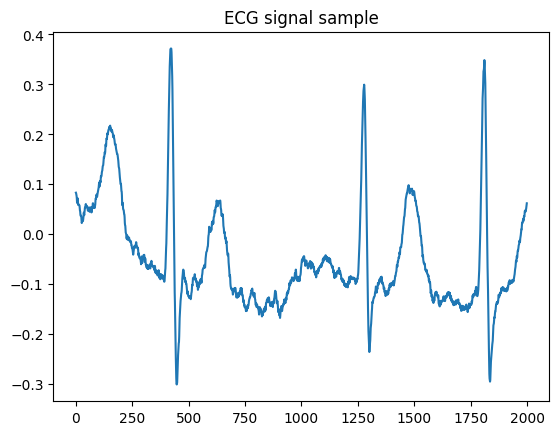

In [6]:
import matplotlib.pyplot as plt

plt.plot(signal[:2000, 0])  # first channel
plt.title("ECG signal sample")
plt.show()

In [7]:
def segment_signal(signal, fs=500, window_sec=3, step_sec=1):
    window = window_sec * fs
    step = step_sec * fs

    segments = []

    for start in range(0, len(signal) - window, step):
        seg = signal[start:start+window]
        segments.append(seg)

    return segments

In [8]:
segments = segment_signal(signal)
print("Total segments:", len(segments))
print("One segment shape:", segments[0].shape)

Total segments: 1209
One segment shape: (1500, 6)


In [9]:
import os

X = []
y = []

files = os.listdir('/content')

for file in files:
    if file.endswith('.hea'):
        name = file.replace('.hea', '')

        record = wfdb.rdrecord('/content/' + name)
        signal = record.p_signal[:, 0]  # use first channel

        segments = segment_signal(signal)

        if name.startswith('NR'):
            label = 0
        else:
            label = 1

        for seg in segments:
            X.append(seg)
            y.append(label)

print("Total samples:", len(X))

Total samples: 31188


In [10]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(31188, 1500)
(31188,)


In [11]:
print(X.shape)

(31188, 1500)


In [12]:
import torch

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# Add channel dimension (VERY IMPORTANT)
X = X.unsqueeze(1)

print(X.shape)

torch.Size([31188, 1, 1500])


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [15]:
import torch.nn as nn

class ECG_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=128),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.MaxPool1d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * 311, 512),  # adjusted for your input
            nn.ReLU(),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECG_CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [17]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 463.5942
Epoch 2, Loss: 434.1634
Epoch 3, Loss: 444.4058
Epoch 4, Loss: 442.0415
Epoch 5, Loss: 433.7362
Epoch 6, Loss: 442.9530
Epoch 7, Loss: 438.4823
Epoch 8, Loss: 419.1441
Epoch 9, Loss: 443.9888
Epoch 10, Loss: 441.2838


In [18]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

print("Accuracy:", correct / total)

Accuracy: 0.6824302661109329


In [19]:
subjects = []

for file in os.listdir('/content'):
    if file.endswith('.hea'):
        name = file.replace('.hea', '')
        subjects.append(name)

subjects = list(set(subjects))
print(len(subjects))

26


In [20]:
from sklearn.model_selection import train_test_split

train_subj, test_subj = train_test_split(subjects, test_size=0.2, random_state=42)

In [21]:
X_train, y_train = [], []
X_test, y_test = [], []

for name in subjects:
    record = wfdb.rdrecord('/content/' + name)
    signal = record.p_signal[:, 0]

    segments = segment_signal(signal)

    label = 0 if name.startswith('NR') else 1

    for seg in segments:
        if name in train_subj:
            X_train.append(seg)
            y_train.append(label)
        else:
            X_test.append(seg)
            y_test.append(label)

In [22]:
def normalize(signal):
    return (signal - np.mean(signal)) / np.std(signal)

X_train = np.array([normalize(x) for x in X_train])
X_test = np.array([normalize(x) for x in X_test])

In [23]:
from collections import defaultdict

subject_preds = defaultdict(list)

model.eval()

with torch.no_grad():
    for i in range(len(X_test)):
        x = torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        output = model(x)
        pred = torch.argmax(output, dim=1).item()

        subject = test_subj[i % len(test_subj)]  # temporary mapping
        subject_preds[subject].append(pred)

In [24]:
final_preds = []
true_labels = []

for subject in subject_preds:
    preds = subject_preds[subject]
    ratio = sum(preds) / len(preds)

    final = 1 if ratio > 0.6 else 0

    final_preds.append(final)
    true_labels.append(0 if subject.startswith('NR') else 1)

In [25]:
from sklearn.metrics import accuracy_score

print("Subject Accuracy:", accuracy_score(true_labels, final_preds))

Subject Accuracy: 0.8333333333333334
